Shape: (300, 4)
       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                69.96         53.23   42.07
std                 33.82         27.41   13.59
min                 14.28          4.10   18.00
25%                 32.14         25.60   30.00
50%                 70.84         55.11   43.00
75%                103.40         78.16   53.00
max                140.79        103.17   64.00


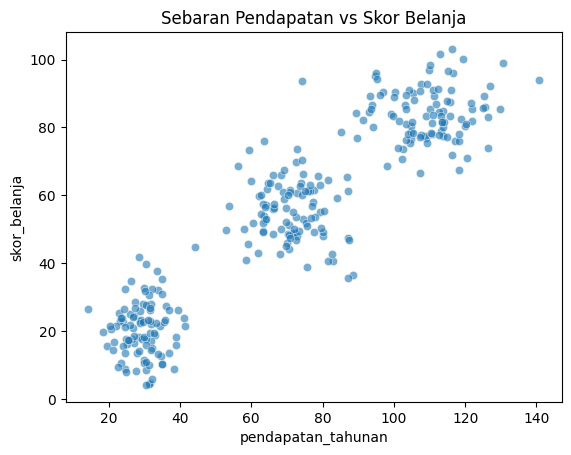

Rata - rata setelah scaling: [-0.  0.]
Std setelah scaling  : [1. 1.]


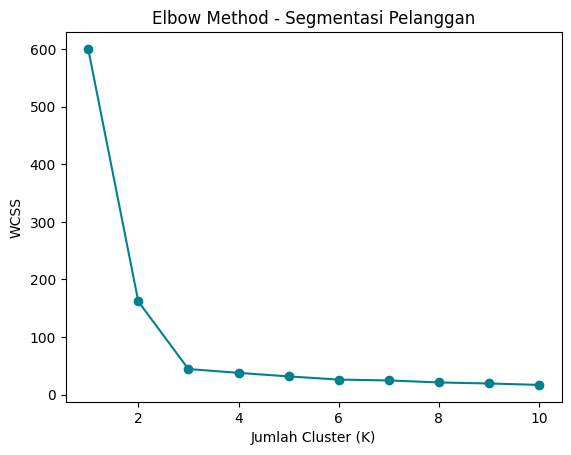

In [10]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

# Generate dataset sintetis pelanggan (3 kelompok tersembunyi)
np.random.seed(42)
grp1 = np.random.normal([30, 20], [6,8], (100, 2)) # hemat
grp2 = np.random.normal([70, 55], [8, 10], (100, 2)) # menengah
grp3 = np.random.normal([110, 85], [10, 8], (100, 2)) # boros
data = np.vstack([grp1, grp2, grp3])

df = pd.DataFrame(data, columns=['pendapatan_tahunan', 'skor_belanja'])
df['usia'] = np.random.randint(18, 65, len(df))
df['gender'] = np.random.choice(['L', 'P'], len(df))

print('Shape:', df.shape)
print(df.describe().round(2))

sns.scatterplot(data=df, x='pendapatan_tahunan', y='skor_belanja', alpha=0.6)
plt.title('Sebaran Pendapatan vs Skor Belanja')
plt.show()

from sklearn.preprocessing import StandardScaler
X = df[['pendapatan_tahunan', 'skor_belanja']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Rata - rata setelah scaling:', X_scaled.mean(axis=0).round(3))
print('Std setelah scaling  :', X_scaled.std(axis=0).round(3))

from sklearn.cluster import KMeans

wcss = []
for k in range(1, 11):
  km = KMeans(n_clusters=k, random_state=42, init='k-means++')
  km.fit(X_scaled)
  wcss.append(km.inertia_)

plt.plot(range(1,11), wcss, marker='o', color='#028090')
plt.xlabel('Jumlah Cluster (K)'); plt.ylabel('WCSS')
plt.title('Elbow Method - Segmentasi Pelanggan')
plt.show()
# Interpretasikan dalam sel Markdown berikutnya:
# - Di K berapa kurva mulai melandai (titik elbow)?
# - Apakah hasilnya sesuai dengan jumlah kelompok yang diharapkan?

# Di K berapa kurva mulai melandai (titik elbow)?
Kurva Elbow mulai melandai pada K = 3.

# Apakah hasilnya sesuai dengan jumlah kelompok yang diharapkan?
Ya. Hasil tersebut sesuai dengan jumlah kelompok yang diharapkan karena dataset memang dibangun dari 3 kelompok pelanggan, yaitu kelompok hemat, menengah, dan boros/premium.

WCSS akhir      : 44.556
Silhoutte Score : 0.695
         pendapatan_tahunan  skor_belanja
cluster                                  
0                     70.99         55.05
1                     29.31         20.27
2                    109.20         84.08


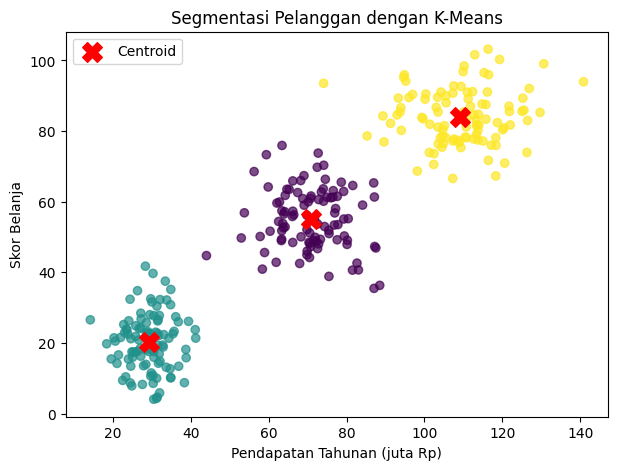

In [11]:
from sklearn.metrics import silhouette_score

model = KMeans(n_clusters=3, random_state=42, init='k-means++')
model.fit(X_scaled)
df['cluster'] = model.labels_

print(f'WCSS akhir      : {model.inertia_:.3f}')
print(f'Silhoutte Score : {silhouette_score(X_scaled, model.labels_):.3f}')
print(df.groupby('cluster')[['pendapatan_tahunan', 'skor_belanja']].mean().round(2))

centroids = scaler.inverse_transform(model.cluster_centers_)

plt.figure(figsize=(7, 5))
plt.scatter(df['pendapatan_tahunan'], df['skor_belanja'], c=df['cluster'], cmap='viridis', alpha=0.7)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroid')
plt.xlabel('Pendapatan Tahunan (juta Rp)')
plt.ylabel('Skor Belanja')
plt.title('Segmentasi Pelanggan dengan K-Means')
plt.legend(); plt.show()
# Interpretasikan tiap cluster, misalnya:
# Cluster 0 = pendapatan rendah, belanja rendah -> segmen 'Hemat'
# Cluster 1 = pendapatan menengah, belanja menengah -> segmen 'Menengah'
# Cluster 2 = pendapatan tinggi, belanja tinggi -> segmen 'Boros/Premium'

Interpretasi hasil clustering:

Cluster 0 → Pendapatan rendah dan skor belanja rendah → Segmen Hemat
Segmen Hemat memiliki daya beli dan tingkat belanja yang relatif rendah sehingga cocok diberikan promosi atau diskon.

Cluster 1 → Pendapatan menengah dan skor belanja menengah → Segmen Menengah
Segmen Menengah merupakan pelanggan dengan karakteristik sedang sehingga dapat ditawarkan program loyalitas untuk meningkatkan pembelian.

Cluster 2 → Pendapatan tinggi dan skor belanja tinggi → Segmen Boros/Premium
Segmen Boros/Premium memiliki pendapatan dan tingkat belanja tinggi sehingga menjadi pelanggan bernilai tinggi yang perlu dipertahankan dengan layanan premium atau penawaran eksklusif.

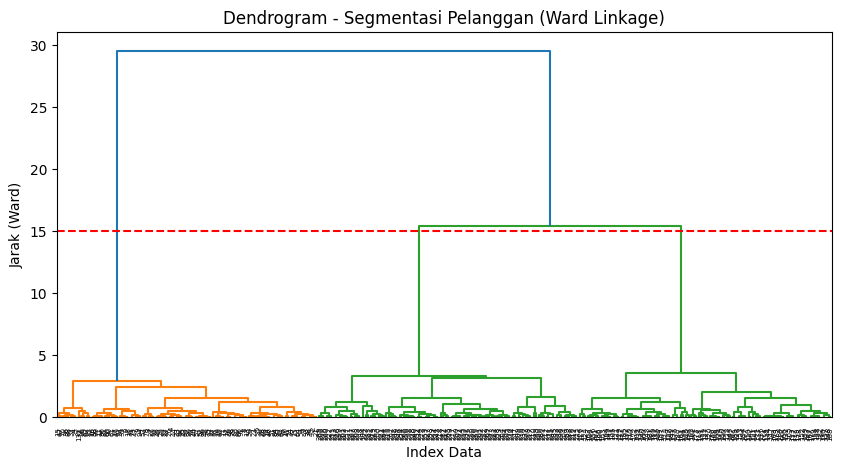

In [12]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title('Dendrogram - Segmentasi Pelanggan (Ward Linkage)')
plt.xlabel('Index Data'); plt.ylabel('Jarak (Ward)')
plt.axhline(y=15, color='red', linestyle='--') # contoh garis potong
plt.show()
# Bandingkan: apakah jumlah cluster dari dendrogram (garis potong)
# konsisten dengan K optimal hasil Metode Elbow pada Langkah 3?

### Bandingkan: apakah jumlah cluster dari dendrogram (garis potong) konsisten dengan K optimal hasil Metode Elbow pada Langkah 3?

Ya, hasil dendrogram konsisten dengan Metode Elbow. Jika garis potong menghasilkan 3 cluster, maka hasil tersebut sesuai dengan nilai K = 3 yang diperoleh dari Metode Elbow. Hal ini menunjukkan bahwa baik metode K-Means maupun Hierarchical Clustering memberikan hasil segmentasi yang sama, sehingga jumlah cluster yang dipilih dapat dianggap optimal untuk dataset tersebut.